In [ ]:
import numpy as np
from tqdm import tqdm
import math

def transformMatrix(A):
    return np.vstack([np.outer(r, r).flatten() for r in A])

matrix_nullSpaceSolution = {}

def streaming_caratheodory(P, w, d):
    
    n = len(P)
    selected_points = P[:d+1]
    selected_weights = w[:d+1]
    
    for i in tqdm(range(d+1, n)):

        selected_points = np.vstack((selected_points, P[i]))
        selected_weights = np.append(selected_weights, w[i])
        w1=selected_weights.sum()
        selected_weights = selected_weights / w1
        # print("Rank in streaming caratheodory", d)
        # Apply Caratheodory's theorem to reduce the set to d+1 points
        selected_points, selected_weights = caratheodory(np.array(selected_points), np.array(selected_weights),d)
        selected_weights = selected_weights* w1
    selected_points, selected_weights = caratheodory(np.array(selected_points), np.array(selected_weights), d)
    return selected_points, selected_weights

def findNullSpace(A, eps=1e-6):
    B = A.flatten()
    if tuple(B) in matrix_nullSpaceSolution:
        return matrix_nullSpaceSolution[tuple(B)]

    U, S, Vt = np.linalg.svd(A)

    # Null space: all vectors in Vt corresponding to 0 singular values
    null_space = Vt.T[:, np.where(S <= eps)[0]]

    if null_space.shape[1] == 0:
        # You can raise or return a fallback vector
        # print(A)
        print(np.linalg.matrix_rank(A)) 
        print(A.shape)
        raise ValueError("Null space is empty — matrix has full row rank.")

    non_trivial_solution = null_space[:, 0]
    matrix_nullSpaceSolution[tuple(B)] = non_trivial_solution
    return non_trivial_solution


import numpy as np

def caratheodory(P, u,rank, dtype='float16'):
    """
    Implementation of the Caratheodory Theorem(1907)
    input: a numpy array P containing n rows (points), each of size d, and a positive vector of weights u (that sums to 1)
    output:a new vector of weights new_u that satisfies :
                1. new_u is positive and sums to 1
                2. new_u has at most d+1 non zero entries
                3. the weighted sum of P and u (input) is the same as the weighted sum of P and new_u (output)
    computation time: O(n^2d^2)
    """
    while 1:
        n = np.count_nonzero(u)
        d = P.shape[1]
        u_non_zero = np.nonzero(u)

        if n <= rank + 1:
            # return u
            # return selected_points and corresponding non zero weights
            selected_points = P[u_non_zero]
            selected_weights = u[u_non_zero]
            selected_weights = selected_weights / np.sum(selected_weights)
            return selected_points, selected_weights

        A = P[u_non_zero]
        reduced_vec = np.outer(A[0], np.ones(A.shape[0]-1, dtype = dtype))
        A = A[1:].T - reduced_vec
        # print("Starting SVD")
        _, _, V = np.linalg.svd(A, full_matrices=True)
        # print("Calculated SVD")

        v=V[-1]
        v = np.insert(v, [0],   -1 * np.sum(v))

        idx_good_alpha = np.nonzero(v > 0)
        alpha = np.min(u[u_non_zero][idx_good_alpha]/v[idx_good_alpha])

        w = np.zeros(u.shape[0] , dtype = dtype)
        tmp_w = u[u_non_zero] - alpha * v
        tmp_w[np.argmin(tmp_w)] = 0.0
        w[u_non_zero] = tmp_w
        w[u_non_zero][np.argmin(w[u_non_zero] )] = 0
        u = w

def fast_caratheodory_set(P, w, k, rank):
    n, d = P.shape
    # print(n, d)
    # Step 1: Remove zero-weight points
    # n= len(P)
    mask = w > 0
    P = P[mask]
    w = w[mask]
    
    # Step 2: Base case
    if len(P) <= rank + 1:
        return P, w

    # Step 4: Partition into k clusters
    partitions = []
    weights_partitions = []
    # k=root(e)*d
    k = int(np.ceil(np.sqrt(math.e) * d))
    if k > len(P):
        k = len(P)
        
    chunk_size = int(np.ceil(len(P) / k))
    if chunk_size<=d+1:
        # print("chunk_size", chunk_size, d+1)
        # print("Remaining points", len(P))
        # print("Rank", rank)
        return streaming_caratheodory(P, w, rank)
    
    for i in range(0, len(P), chunk_size):
        partitions.append(P[i:i + chunk_size])
        weights_partitions.append(w[i:i + chunk_size])

    # Step 5-7: Compute weighted means and cluster weights
    means = []
    new_weights = []
    for Pi, wi in zip(partitions, weights_partitions):
        total_w = np.sum(wi)
        mean = np.dot(wi, Pi) / total_w
        means.append(mean)
        new_weights.append(total_w)
    means = np.array(means)
    new_weights = np.array(new_weights)

    # Step 8: Carathéodory   n cluster means

    reduced_means, reduced_weights = caratheodory(means, new_weights, P.shape[1])

    # Step 9-11: Collect and reweight points from chosen clusters
    C = []
    final_weights = []

    for mean_point, weight in zip(reduced_means, reduced_weights):
        idx = np.where(np.all(means == mean_point, axis=1))[0][0]
        Pi = partitions[idx]
        wi = weights_partitions[idx]
        total_w = np.sum(wi)
        for p, wp in zip(Pi, wi):
            C.append(p)
            final_weights.append(weight * wp / total_w)

    C = np.array(C)
    final_weights = np.array(final_weights)

    # Step 12: Recursive call
    return fast_caratheodory_set(C, final_weights, k, rank)






In [92]:
import pandas as pd

# df= pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False, na_values=["nan", "?"])
# df=pd.read_csv("sgemm_product.csv", sep=",", low_memory=False, na_values=["nan", "?"])
df=pd.read_csv("OnlineNewsPopularity.csv", sep=",", low_memory=False, na_values=["nan", "?"])
df = df.dropna()
df.head(4)

,Wecked_Data/WECKED_Data_File.ipynburl,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.0,0.0000,0.5,0.0000,1200


In [93]:
# Drop 'url' column if it exists
if 'url' in df.columns:
    df = df.drop(columns=['url'])


In [94]:
df.describe()
# drop all non numeric columns
df = df.select_dtypes(include=[np.number])


In [95]:
# create X and Y matrix using df
X = df.drop(columns=[' shares']).values
y= df[' shares'].values

In [96]:
X.shape

(39644, 59)

In [97]:
from sklearn.model_selection import train_test_split

# Perform truncated SVD on the original data
def truncated_svd(A, k):
    # Compute the SVD of A
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    
    # Keep only the top k singular values and corresponding vectors
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    
    return U_k, S_k, Vt_k

# Apply truncated SVD to reduce the dimensionality of A
k = 10 # Number of dimensions to keep
X, S1, V1 = truncated_svd(X, k)

# normalize X
X= (X - X.mean()) / X.std()

# # make A' using x_test and y_test by concatenating x_test and y_test
# A_test=np.concatenate((x_test, y_test.reshape(-1, 1)), axis=1)
# # Apply truncated SVD to reduce the dimensionality of A_test
# U2, S2, V2 = truncated_svd(A_test, k)

# reconstruct x_test and y_test using U2, S2, V2 by splitting the last row as y_test


In [98]:
import numpy as np
X=np.array(X)
y=np.array(y)
# split into 70:30 ratio

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# print(x_train.shape)

In [100]:
def transformMatrix(A):
    return np.vstack([np.outer(r, r).flatten() for r in A])

In [ ]:
import numpy as np

# Make a matrix of the type [X y \n sqrt(lambda)*I 0]
def makeMatrix(X, y, lmbda):
    n = X.shape[0]  # Number of samples
    d = X.shape[1]  # Number of features
    
    # Initialize the matrix A
    A = np.zeros((n + d, d + 1))
    
    # Fill the top part with X and y
    A[:n, :d] = X
    A[:n, d] = y
    # Add the regularization term (sqrt(lambda) * I)
    A[n:, :d] = np.sqrt(lmbda) * np.eye(d)
    return A

# Example usage
# X = np.random.rand(20, 3)  # Example feature matrix
# y = np.random.rand(20)      # Example target vector
# A = makeMatrix(x_train, y_train, 0.1)
# print(A)

In [102]:
import time
def fit_model(P, A_or, y_or):
    X=P[:,:-1]
    y=P[:,-1]
    start = time.perf_counter()
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    # print(w.shape)
    # print(A_or.shape)
    end = time.perf_counter()
    y_pred = A_or @ w
    rmse = np.sqrt(np.mean((y_or - y_pred) ** 2))
    return w, rmse,( end-start)*1000



In [107]:
n_non_regularization_points = []
coreset_construction_timings=[]
kernalization_timings=[]
# A=A
for lambda_ in  [  1_00_00, 1_00_0,3_00, 1_00, 1_0, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]:
    A = makeMatrix(x_train, y_train, lambda_)
    st1=time.perf_counter()
    M1=transformMatrix(A)
    en1=time.perf_counter()
    kernalization_timings.append((en1-st1)*1000)
    u1=np.ones(M1.shape[0])/len(M1)
    d=M1.shape[1]

    rank = np.linalg.matrix_rank(M1)
    print("Rank of M1:", rank)
    # print(M1[0])
    # print(M1[-1])
    # print(M1[-2])
    st2=time.perf_counter()
    c, u= fast_caratheodory_set(M1, u1, d,rank)
    en2=time.perf_counter()
    coreset_construction_timings.append((en2-st2)*1000)

    # print(c)
    # count the number of regularization points in the coreset
    num_regularization_points = np.count_nonzero(c[:, -1])
    print("Number of regularization points in the coreset:", num_regularization_points)
    # print the RMSE on both coreset and original data


    coreset_points, coreset_weights=c, u
    u=u/sum(u)
    final_points=[]
    for i in range(len(coreset_points)):
        m1=coreset_points[i].reshape(A.shape[1] ,A.shape[1]) 
        x1=np.array([np.sqrt(x) for x in np.diag(m1)])*np.sqrt(coreset_weights[i])
        final_points.append(x1)
    final_points=np.array(final_points)

    w1, rmse_coreset, time_coreset = fit_model(final_points, x_test, y_test)

    # calculate the loss and model fit time for the original data
    w2, rmse_original, time_original = fit_model(A, x_test, y_test)
    # print a comparision
    print("Lambda:", lambda_)
    print("Time taken for coreset model fitting:", time_coreset)
    print("RMSE for coreset data:", rmse_coreset)
    print("RMSE for original data:", rmse_original)
    print("Time taken for model fit on original data:", time_original)
    

    # print("Coreset Construction time:", (en2-st2)*1000)
    print("Kernalization time:", (en1-st1)*1000)
    # print("RMSE for Coreset data:", rmse)
    n_non_regularization_points.append(num_regularization_points)
# print("Caratheodory weights:")
# print(w)
# prisnt("Caratheodory weights sum:")
# print(np.sum(w)) 
# print("Caratheodory weights non-zero:")
# print(np.count_nonzero(w))

Rank of M1: 66


100%|██████████| 16851/16851 [00:08<00:00, 1921.44it/s]


Number of regularization points in the coreset: 57
Lambda: 10000
Time taken for coreset model fitting: 0.03141699926345609
RMSE for coreset data: 13826.012417037184
RMSE for original data: 13076.698587417983
Time taken for model fit on original data: 0.9866670006886125
Kernalization time: 65.51254199985124
Rank of M1: 66


100%|██████████| 16851/16851 [00:09<00:00, 1788.37it/s]


Number of regularization points in the coreset: 59
Lambda: 1000
Time taken for coreset model fitting: 0.026708999939728528
RMSE for coreset data: 13919.053206181465
RMSE for original data: 13009.016455963669
Time taken for model fit on original data: 0.9941250009433134
Kernalization time: 59.51179099974979
Rank of M1: 66


...

Number of regularization points in the coreset: 67
Lambda: 0.001
Time taken for coreset model fitting: 0.026915999114862643
RMSE for coreset data: 14998.504523332093
RMSE for original data: 13005.39948294047
Time taken for model fit on original data: 0.9946660011337372
Kernalization time: 56.75275000066904
Rank of M1: 66


100%|██████████| 16891/16891 [00:09<00:00, 1699.85it/s]


Number of regularization points in the coreset: 67
Lambda: 0.0001
Time taken for coreset model fitting: 0.02991600013046991
RMSE for coreset data: 14988.579382077016
RMSE for original data: 13005.39948057346
Time taken for model fit on original data: 0.970041999607929
Kernalization time: 57.617708000179846
Rank of M1: 66


100%|██████████| 16891/16891 [00:08<00:00, 1976.22it/s]

Number of regularization points in the coreset: 67
Lambda: 1e-05
Time taken for coreset model fitting: 0.02683300044736825
RMSE for coreset data: 14699.034521045889
RMSE for original data: 13005.399480336759
Time taken for model fit on original data: 1.0496670001884922
Kernalization time: 57.94758299998648


In [110]:
# print a table of lambda values vs coreset construction time and kernalization time and print the avergae

import pandas as pd

lambda_values = [  1_00_00, 1_00_0,3_00, 1_00, 1_0, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
df = pd.DataFrame({
    'Lambda': lambda_values,
    'Coreset Construction Time (ms)': coreset_construction_timings,
    'Kernalization Time (ms)': kernalization_timings,
    'Number of Regularization Points': n_non_regularization_points
})

print(df)

# print the average of coreset construction time and kernalization time
average_coreset_time = np.mean(coreset_construction_timings)
average_kernalization_time = np.mean(kernalization_timings)
print("Average Coreset Construction Time (ms):", average_coreset_time)
print("Average Kernalization Time (ms):", average_kernalization_time)

         Lambda  Coreset Construction Time (ms)  Kernalization Time (ms)  \
0   10000.00000                     8944.969500                65.512542   
1    1000.00000                     9532.774292                59.511791   
2     300.00000                     9616.863667                60.526000   
3     100.00000                    10916.252500                57.364541   
4      10.00000                     9904.634042                65.128750   
5       1.00000                     8587.928375                64.206584   
6       0.10000                     8848.665834                57.716500   
7       0.01000                     8968.882709                57.202375   
8       0.00100                     8996.471334                56.752750   
9       0.00010                    10048.715375                57.617708   
10      0.00001                     8651.251042                57.947583   

    Number of Regularization Points  
0                                57  
1          

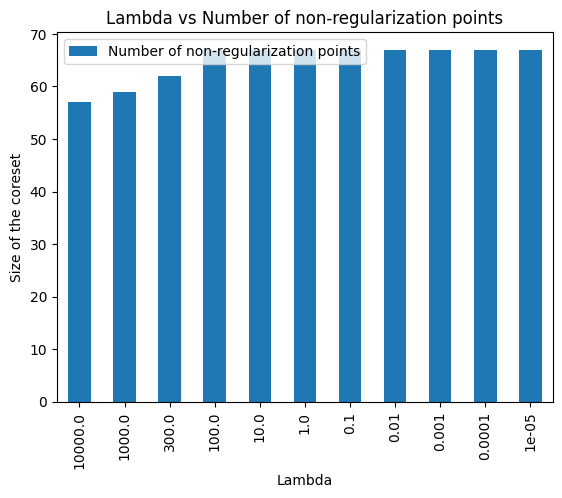

             Number of non-regularization points
Lambda                                          
10000.00000                                   57
1000.00000                                    59
300.00000                                     62
100.00000                                     67
10.00000                                      67
1.00000                                       67
0.10000                                       67
0.01000                                       67
0.00100                                       67
0.00010                                       67
0.00001                                       67


In [111]:
# create a table for Lambda vs the number of non-regularization points in the coreset
import pandas as pd
import matplotlib.pyplot as plt

lambdas=  [  1_00_00, 1_00_0,3_00, 1_00, 1_0, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
df = pd.DataFrame({'Lambda': lambdas, 'Number of non-regularization points': n_non_regularization_points})
df = df.set_index('Lambda')
df.plot(kind='bar')
plt.xlabel('Lambda')
plt.ylabel('Size of the coreset')
plt.title('Lambda vs Number of non-regularization points')
plt.show()
print(df)


In [112]:
# multiple root(u) with c
for i in range(len(c)):
    c[i] = c[i] * np.sqrt(u[i])
print(c)

[[ 1.10269607e-02  1.43231741e-02  2.71607959e-02 ... -6.26973606e+01
   1.48142208e+02  3.02957715e+03]
 [ 1.65204733e-02 -3.65268929e-03  1.20959442e-01 ... -7.25781360e+01
   3.34023332e+01  8.61583493e+04]
 [ 4.49165396e-02  8.30807246e-02 -1.08147800e-01 ...  4.21855515e+03
  -4.85509511e+03  1.44496579e+08]
 ...
 [ 5.32644444e-02  1.07145267e-02  2.03292305e-02 ...  3.72690526e+00
   4.16931546e+01  1.20268032e+05]
 [ 8.15626116e-03  3.67215519e-02 -3.00832929e-02 ... -3.99065228e+01
   9.07280583e+00  3.38082891e+04]
 [ 4.29825393e-02  6.75448830e-02  5.07327038e-02 ...  3.49267111e+01
   1.52719867e+00  3.12370883e+04]]


In [113]:
coreset_points, coreset_weights=c, u
final_points=[]
for i in range(len(coreset_points)):
    m1=coreset_points[i].reshape(A.shape[1] ,A.shape[1]) 
    x1=np.array([np.sqrt(x) for x in np.diag(m1)])*np.sqrt(coreset_weights[i])
    final_points.append(x1)
final_points=np.array(final_points)

In [114]:
import time
def fit_model(P, A_or, y_or):
    X=P[:,:-1]
    y=P[:,-1]
    start = time.perf_counter()
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    print(w.shape)
    print(A_or.shape)
    end = time.perf_counter()
    y_pred = A_or @ w
    rmse = np.sqrt(np.mean((y_or - y_pred) ** 2))
    return w, rmse,( end-start)*1000



In [115]:
w1, rmse1, time1= fit_model(final_points, x_test, y_test)
print("RMSE for Coreset data:", rmse1)
print("Time taken for coreset data:", time1)


(10,)
(11894, 10)
RMSE for Coreset data: 13983.71264959452
Time taken for coreset data: 0.07525000000896398


In [116]:
original_data = np.concatenate((x_train, y_train.reshape(-1, 1)), axis=1)
w1, rmse1, time1= fit_model(original_data, x_test, y_test)
print("RMSE for Original  data:", rmse1)
print("Time taken for Original data:", time1)


(10,)
(11894, 10)
RMSE for Original  data: 13005.39948031046
Time taken for Original data: 1.2069160002283752


In [117]:
def check_corset(original, Coreset):
    original=original/np.sqrt(len(original))
    CoresetT=np.array(Coreset).T
    CTC=np.dot(CoresetT,Coreset)
    OTO=np.dot(original.T,original)
    flag=True
    for i in range(len(OTO)):
        for j in range(len(OTO[0])):
            if abs(OTO[i][j]-CTC[i][j])>0.0001:
                flag=False
                break
    return flag

print("Check Coreset:")
print(check_corset(original_data, final_points))

Check Coreset:
False


In [118]:
import random
import numpy as np
import time
import pandas as pd  # Ensure pandas is imported for creating the table

# Define the mapping of size to lambda
size_toLambda = {
    58: 10_000, 
    62: 1_000,
    64: 300,
    64: 100,
    65: 10,
    65: 1,
    67: 0.1,
    67: 0.01,
    67: 0.001,
    67: 0.0001,
    67: 0.00001
}

# Perform random sampling for sizes between 57 and 67
all_rmse = []
all_time = []
all_lambdas = []

for i in range(1):  # Repeat the process if needed
    rmse_list = []
    time_list = []
    lambda_list = []

    for size in range(57, 68):  # Sizes between 57 and 67
        t1 = time.perf_counter()
        
        # Skip sizes not in the mapping
        if size not in size_toLambda:
            continue
        
        # Get the corresponding lambda
        lambda_ = size_toLambda[size]

        # Create the matrix A using the given lambda
        A = makeMatrix(x_train, y_train, lambda_)
        
        # Randomly sample indices
        sampled_indices = random.sample(range(A.shape[0]), size)
        sampled_data = A[sampled_indices]
        
        t2 = time.perf_counter()
        
        # Fit the model using the sampled data
        w2, rmse2, time2 = fit_model(sampled_data, x_test, y_test)
    
        # Store RMSE, time, and lambda
        rmse_list.append(rmse2)
        time_list.append(time2 + (t2 - t1) * 1000)  # Include sampling time in total time
        lambda_list.append(lambda_)
        
        print(f"Lambda: {lambda_}, Size: {size}, RMSE: {rmse2}, Time: {time2 + (t2 - t1) * 1000} ms")
    
    all_rmse.append(rmse_list)
    all_time.append(time_list)
    all_lambdas.append(lambda_list)

# Calculate averages
average_times = np.mean(all_time, axis=0)
average_rmse = np.mean(all_rmse, axis=0)
average_lambdas = np.mean(all_lambdas, axis=0)

# Create a DataFrame to display the results
df1 = pd.DataFrame({
    'Size': list(size_toLambda.keys()),
    'Lambda': list(size_toLambda.values()),
    'RMSE': average_rmse,
    'Time (ms)': average_times
})

# Print the table
print(df1)

# Print overall averages
print("\nAverage RMSE:", average_rmse)
print("Average Time (ms):", average_times)

(10,)
(11894, 10)
Lambda: 10000, Size: 58, RMSE: 13280.820726749529, Time: 0.8193749999918509 ms
(10,)
(11894, 10)
Lambda: 1000, Size: 62, RMSE: 13209.210219108258, Time: 0.3314579989819322 ms
(10,)
(11894, 10)
Lambda: 100, Size: 64, RMSE: 15788.558998000944, Time: 0.28645899874391034 ms
(10,)
(11894, 10)
Lambda: 1, Size: 65, RMSE: 19022.469145055653, Time: 0.25437499971303623 ms
(10,)
(11894, 10)
Lambda: 1e-05, Size: 67, RMSE: 18691.665725575614, Time: 0.25875000028463546 ms
   Size       Lambda          RMSE  Time (ms)
0    58  10000.00000  13280.820727   0.819375
1    62   1000.00000  13209.210219   0.331458
2    64    100.00000  15788.558998   0.286459
3    65      1.00000  19022.469145   0.254375
4    67      0.00001  18691.665726   0.258750

Average RMSE: [13280.82072675 13209.21021911 15788.558998   19022.46914506
 18691.66572558]
Average Time (ms): [0.819375 0.331458 0.286459 0.254375 0.25875 ]


In [119]:
import numpy as np
import time
import pandas as pd
from sklearn.utils.extmath import randomized_svd
from sklearn.utils import check_random_state

# Leverage score sampling function
def leverage_score_sampling(A, n_samples, random_state=None):
    rng = check_random_state(random_state)
    U, _, _ = randomized_svd(A, n_components=min(A.shape)-1, random_state=rng)
    leverage_scores = np.sum(U**2, axis=1)
    leverage_scores /= np.sum(leverage_scores)
    sampled_indices = rng.choice(A.shape[0], size=n_samples, replace=False, p=leverage_scores)
    return sampled_indices


# Define the mapping of size to lambda
size_toLambda = {
    58: 10_000, 
    62: 1_000,
    64: 300,
    64: 100,
    65: 10,
    65: 1,
    67: 0.1,
    67: 0.01,
    67: 0.001,
    67: 0.0001,
    67: 0.00001
}

# Set up
runs = 5
sizes = list(range(57, 68))
rmse_dict = {size: [] for size in sizes}
time_dict = {size: [] for size in sizes}

# Run 5 iterations
for run in range(runs):
    print(f"\nRun {run + 1}")
    for size in sizes:
        # Skip sizes not in the mapping
        if size not in size_toLambda:
            continue
        lambda_ = size_toLambda[size]
        A = makeMatrix(x_train, y_train, lambda_)
        t1 = time.perf_counter()
        sampled_indices = leverage_score_sampling(A, size, random_state=run + size)
        sampled_data = A[sampled_indices]
        t2 = time.perf_counter()

        # Fit the model using the sampled data
        w, rmse, t_fit = fit_model(sampled_data, x_test, y_test)
        
        total_time = t_fit + (t2 - t1) * 1000
        rmse_dict[size].append(rmse)
        time_dict[size].append(total_time)
        
        print(f"Size: {size}, Lambda: {lambda_}, RMSE: {rmse:.6f}, Time: {total_time:.4f} ms")

# Create a table of average RMSE, time, and lambda for each size
df2 = pd.DataFrame({
    'Size': sizes,
    'Lambda': [size_toLambda[size] if size in size_toLambda else None for size in sizes],
    'Avg RMSE': [np.mean(rmse_dict[size]) for size in sizes],
    'Avg Time (ms)': [np.mean(time_dict[size]) for size in sizes]
})

print("\n=== AVERAGE RESULTS ===")
print(df2)

# Print averages in a formatted way
print("\n=== AVERAGE RESULTS OVER 5 RUNS ===")
print(f"{'Size':<6}{'Lambda':<10}{'Avg RMSE':<12}{'Avg Time (ms)':<15}")
for size in sizes:
    if size not in size_toLambda:
        continue
    avg_rmse = np.mean(rmse_dict[size])
    avg_time = np.mean(time_dict[size])
    lambda_ = size_toLambda[size]
    print(f"{size:<6}{lambda_:<10}{avg_rmse:<12.6f}{avg_time:<15.4f}")


Run 1


(10,)
(11894, 10)
Size: 58, Lambda: 10000, RMSE: 13546.013290, Time: 21.0672 ms
(10,)
(11894, 10)
Size: 62, Lambda: 1000, RMSE: 23370.525763, Time: 17.8737 ms
(10,)
(11894, 10)
Size: 64, Lambda: 100, RMSE: 78752.533702, Time: 16.7430 ms
(10,)
(11894, 10)
Size: 65, Lambda: 1, RMSE: 78997.931940, Time: 16.4936 ms
(10,)
(11894, 10)
Size: 67, Lambda: 1e-05, RMSE: 37347.251862, Time: 13.4610 ms

Run 2
(10,)
(11894, 10)
Size: 58, Lambda: 10000, RMSE: 33876.481248, Time: 15.1749 ms
(10,)
(11894, 10)
Size: 62, Lambda: 1000, RMSE: 34107.242840, Time: 15.5498 ms
(10,)
(11894, 10)
Size: 64, Lambda: 100, RMSE: 34993.765510, Time: 13.9879 ms
(10,)
(11894, 10)
Size: 65, Lambda: 1, RMSE: 16814.549419, Time: 13.2578 ms
(10,)
(11894, 10)
Size: 67, Lambda: 1e-05, RMSE: 39824.763142, Time: 14.6931 ms

Run 3
(10,)
(11894, 10)
Size: 58, Lambda: 10000, RMSE: 13593.918546, Time: 14.6349 ms
(10,)
(11894, 10)
Size: 62, Lambda: 1000, RMSE: 88113.655187, Time: 15.5681 ms
(10,)
(11894, 10)
Size: 64, Lambda: 100, 

/Users/sanskar.ranjan/Desktop/College/BTP/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sanskar.ranjan/Desktop/College/BTP/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
